# NetFlow Traffic Unsupervised Classification Lab

This notebook builds an **unsupervised clustering** model for network flow (NetFlow/IPFIX-style) records.

## Objectives
- Treat each row as a *single network flow record* and group similar flows into **clusters** without using labels.
- Build a reusable end-to-end pipeline (preprocessing → clustering model).
- Learn how to choose a reasonable number of clusters using an internal metric (silhouette score) and/or the elbow method.
- Interpret clusters by looking at **cluster sizes**, **feature patterns**, and (optionally) how clusters relate to an existing `Label` column.

## What is clustering?
Clustering is an unsupervised learning task: instead of predicting a known target, we try to **discover structure** in the data by grouping examples that look similar in feature space.

In a NetFlow context, clustering can help you:
- Explore traffic mixes when you don’t have reliable labels.
- Identify sub-populations (e.g., different behaviors inside “VPN”).
- Detect unusual groups (small clusters) that may correspond to rare activity.

## Important note about labels
This lab is **unsupervised**, so we will **not** use `Label` to fit the clustering model. If `Label` exists, we may use it **afterwards** to interpret what the clusters correspond to (sanity check / mapping), but that is not required for clustering to work.

In [15]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
# Optional plotting (the notebook still runs if matplotlib is unavailable)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print('Matplotlib not available, skipping plots:', e)

# Optional rich display (works in Jupyter; we fall back to print if missing)
try:
    from IPython.display import display
except Exception:
    display = None

In [17]:
# Load dataset (flows.csv should be next to this notebook)
df = pd.read_csv('flows.csv')
df.head(10)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label
0,25405,443,17,7708.731622,379.0,94.0,210724.0,50384.0,33871.720121,61.358992,0,0,0,VPN
1,55432,8080,6,3024.530486,122.0,1098.0,27084.0,976122.0,331689.829065,403.368392,1,7,1,VIDEO
2,56850,443,6,5081.732696,89.0,44.0,56782.0,34848.0,18031.251441,26.172176,2,6,0,BULK
3,49672,5061,17,5859.682646,308.0,119.0,19404.0,13209.0,5565.659776,72.870841,0,0,0,VOIP
4,50499,443,6,4686.218441,44.0,76.0,16940.0,70072.0,18567.636378,25.607001,1,5,1,WEB
5,33357,443,6,8476.412156,114.0,34.0,126540.0,26894.0,18101.290639,17.460218,2,1,1,BULK
6,15748,443,6,3062.836794,266.0,391.0,139118.0,143106.0,92144.642045,214.507022,0,6,0,VPN
7,39782,443,6,3693.393050,116.0,88.0,30160.0,37840.0,18411.254657,55.233764,2,7,0,VPN
8,64991,443,17,2495.019157,34.0,53.0,2346.0,46163.0,19442.335691,34.869472,0,0,0,WEB
9,48358,1935,6,4272.714279,45.0,637.0,4545.0,348439.0,82613.527832,159.617507,2,5,0,VIDEO


## Preparing the data for clustering

Clustering algorithms work in a geometric space: they compare points using distances. That means we need to build a clean, numeric representation of each flow.

The preprocessing steps below follow the same principles as in the supervised lab:
- **Drop or separate the `Label` column**: clustering should not use the target.
- Split columns into **numeric** vs **categorical**.
- Handle missing values (median for numeric, most-frequent for categorical).
- Scale numeric features so that large-magnitude fields (e.g., bytes) do not dominate distance calculations.
- One-hot encode categorical features so they become numeric.

Why scaling matters even more in clustering:
- K-Means is distance-based; if one feature has a much larger scale, it can dominate the notion of “similarity”.

Practical detail for K-Means + one-hot encoding:
- K-Means typically expects a **dense** numeric array, so we configure the one-hot encoder to output a dense matrix.

In [18]:
# Separate features from label (if present)
has_label = 'Label' in df.columns
y = df['Label'] if has_label else None
X = df.drop(columns=['Label']) if has_label else df.copy()

# Identify numeric vs categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Keep OneHotEncoder dense for KMeans compatibility
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric feature count:', len(numeric_features))
print('Categorical feature count:', len(categorical_features))
numeric_features[:10], categorical_features[:10]

Numeric feature count: 13
Categorical feature count: 0


(['SrcPort',
  'DstPort',
  'Protocol',
  'FlowDurationMs',
  'TotFwdPkts',
  'TotBwdPkts',
  'TotLenFwdBytes',
  'TotLenBwdBytes',
  'FlowBytsPerS',
  'FlowPktsPerS'],
 [])

## Choosing the number of clusters (K)

K-Means requires us to choose **K**, the number of clusters. There is no single perfect answer in unsupervised learning, but we can use internal diagnostics:

- **Inertia (elbow method)**: how compact clusters are (sum of squared distances to centroids). Inertia decreases as K increases; we look for a point where improvements start diminishing.
- **Silhouette score**: measures how well-separated clusters are. Higher is better (roughly between -1 and 1).

To keep runtime manageable, we estimate these metrics on a random sample of flows. This is usually enough to spot a reasonable range for K.

In [19]:
# Transform the dataset once
X_trans = preprocess.fit_transform(X)

rng = np.random.default_rng(42)
n = X_trans.shape[0]
sample_size = min(5000, n)
sample_idx = rng.choice(n, size=sample_size, replace=False)
X_trans_sample = X_trans[sample_idx]

rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_sample = km.fit_predict(X_trans_sample)
    sil = silhouette_score(X_trans_sample, labels_sample)
    rows.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

k_summary = pd.DataFrame(rows)
k_summary

,k,inertia,silhouette
0,2,52865.086104,0.234293
1,3,42492.318367,0.255938
2,4,37866.925039,0.241951
3,5,34891.566693,0.221470
4,6,32302.257637,0.197117
5,7,30227.976546,0.195137
6,8,28742.095009,0.198948
7,9,27602.935404,0.199365
8,10,26664.441792,0.185172


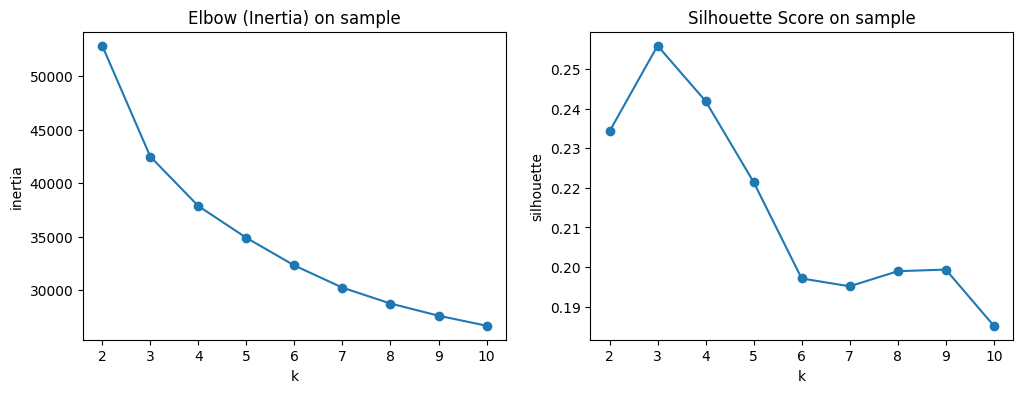

In [20]:
# Optional plot of elbow + silhouette
if HAS_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(k_summary['k'], k_summary['inertia'], marker='o')
    ax[0].set_title('Elbow (Inertia) on sample')
    ax[0].set_xlabel('k')
    ax[0].set_ylabel('inertia')

    ax[1].plot(k_summary['k'], k_summary['silhouette'], marker='o')
    ax[1].set_title('Silhouette Score on sample')
    ax[1].set_xlabel('k')
    ax[1].set_ylabel('silhouette')
    plt.show()

## Fit the final clustering model (K-Means)

Below we build a single `Pipeline` that includes preprocessing and K-Means.

As a starting point, we can try **K = 5** (often a reasonable baseline if your dataset contains around five broad traffic groups). If your silhouette/elbow analysis suggests a different K, update the value and re-run.

Remember: unsupervised clusters are not guaranteed to match human labels 1-to-1. Clusters may split one label into multiple behaviors, or merge two labels that look similar in flow statistics.

In [21]:
k_final = 5

clusterer = Pipeline([
    ('preprocess', preprocess),
    ('model', KMeans(n_clusters=k_final, n_init=10, random_state=42))
])

clusterer.fit(X)
clusters = clusterer.predict(X)

df_clusters = df.copy()
df_clusters['cluster'] = clusters

print('Cluster sizes:')
df_clusters['cluster'].value_counts().sort_index()

Cluster sizes:


cluster
0     5474
1     8043
2     5996
3    22221
4     8266
Name: count, dtype: int64

## Interpreting clusters (what do they represent?)

A good first step is to look at:
- **Cluster sizes**: very small clusters can indicate rare traffic patterns or outliers.
- **Feature summaries per cluster**: do clusters differ in packet counts, bytes, or ports?

If `Label` exists, we can also compute a **contingency table** (`Label` × `cluster`) to see which true labels dominate each cluster. This is not used for training; it is only a post-hoc interpretation tool.

In [22]:
# Numeric summaries per cluster (means) to get a feel for cluster behavior
num_cols = df_clusters.drop(columns=['Label'], errors='ignore').select_dtypes(include=['int64', 'float64']).columns
summary = df_clusters.groupby('cluster')[num_cols].mean(numeric_only=True)
summary.head()

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt
cluster,,,,,,,,,,,,,
0,33559.374315,12692.377055,16.443369,4497.253327,317.221228,277.564669,42272.269638,3.744557e+04,23404.183868,170.559257,0.047315,0.225977,0.023566
1,33363.276514,2220.302996,16.827676,4675.283779,95.444237,227.006465,27343.223921,1.444125e+05,41569.758102,84.500442,0.000373,0.022504,0.000000
2,33361.070213,1958.215811,10.037859,5386.450066,111.530354,1090.219480,21314.694963,1.056380e+06,278499.927398,316.087362,0.625083,3.118412,0.311541
3,33233.968363,972.818820,6.000000,3878.849978,50.272175,105.202511,16205.297106,7.519130e+04,27320.010645,50.515489,1.011566,5.043877,0.502723
4,33264.323615,1204.432857,6.356642,3886.068749,223.864868,175.589523,122086.154246,9.327551e+04,82798.542147,164.993303,0.974232,4.852528,0.481128


In [23]:
# If labels exist, show how clusters relate to labels (post-hoc interpretation)
if has_label:
    ct = pd.crosstab(df_clusters['Label'], df_clusters['cluster'])
    print('Label x Cluster counts:')
    (display(ct) if display is not None else print(ct))

    # Normalized view: for each label, what fraction falls into each cluster?
    ct_norm = pd.crosstab(df_clusters['Label'], df_clusters['cluster'], normalize='index')
    print('Label x Cluster fractions (rows sum to 1):')
    (display(ct_norm) if display is not None else print(ct_norm))

    # Simple cluster purity (not perfect, but a useful summary)
    purity = ct.max(axis=0).sum() / ct.to_numpy().sum()
    print(f'Cluster purity (post-hoc vs Label): {purity:.3f}')
else:
    print('No Label column found; skipping label-vs-cluster interpretation.')

Label x Cluster counts:


cluster,0,1,2,3,4
Label,,,,,
BULK,0,964,5,2900,3560
VIDEO,5,1842,5958,1985,144
VOIP,5326,1677,0,241,253
VPN,143,904,33,2295,4309
WEB,0,2656,0,14800,0


Label x Cluster fractions (rows sum to 1):


cluster,0,1,2,3,4
Label,,,,,
BULK,0.000000,0.129762,0.000673,0.390362,0.479203
VIDEO,0.000503,0.185424,0.599758,0.199819,0.014496
VOIP,0.710418,0.223689,0.000000,0.032146,0.033747
VPN,0.018610,0.117647,0.004295,0.298673,0.560776
WEB,0.000000,0.152154,0.000000,0.847846,0.000000


Cluster purity (post-hoc vs Label): 0.661


## (Optional) 2D visualization with PCA

To visualize clusters, we can project the high-dimensional feature space down to 2D using PCA.

Caveats:
- PCA is a linear projection; 2D plots can hide structure present in higher dimensions.
- With one-hot encoded categorical features, PCA is only a rough visualization tool.

Still, it is useful to check whether clusters are at least partially separable.

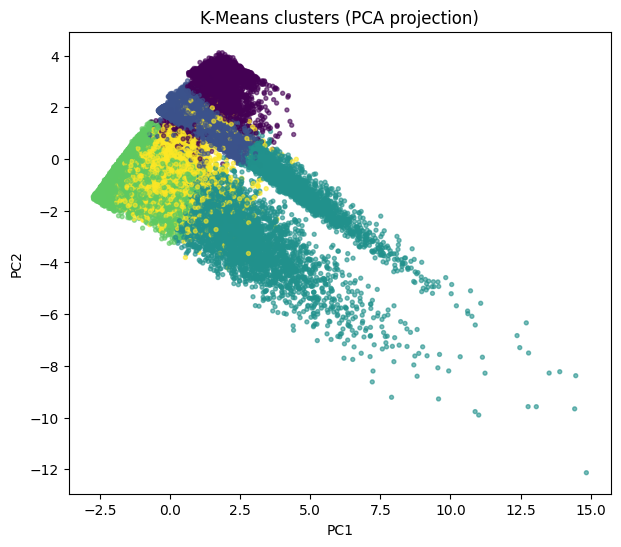

In [24]:
if HAS_MPL:
    from sklearn.decomposition import PCA

    X_trans_final = clusterer.named_steps['preprocess'].transform(X)
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_trans_final)

    plt.figure(figsize=(7, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=8, alpha=0.6)
    plt.title('K-Means clusters (PCA projection)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()
else:
    print('Matplotlib not available; skipping PCA plot.')